In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
train = pd.read_csv("liar_dataset/train.tsv", sep="\t",header=None)
validation = pd.read_csv("liar_dataset/valid.tsv", sep="\t", header=None)
test = pd.read_csv("liar_dataset/test.tsv", sep="\t", header=None)

print("Train shape:     ", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:      ", test.shape)

print(train.columns)

Train shape:      (10240, 14)
Validation shape: (1284, 14)
Test shape:       (1267, 14)
Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], dtype='int64')


In [4]:
# Keep relevant columns and rename
cols = ['label', 'statement', 'subject', 'speaker', 'state','job',
        'party', 'pants_fire_counts', 'false_counts',
        'barely_true_counts', 'half_true_counts', 'true_counts','context']

train      = train[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,13]]
validation = validation[[1, 2, 3, 4, 5,6, 7, 8, 9, 10, 11, 12,13]]
test       = test[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,13]]

train.columns      = cols
validation.columns = cols
test.columns       = cols


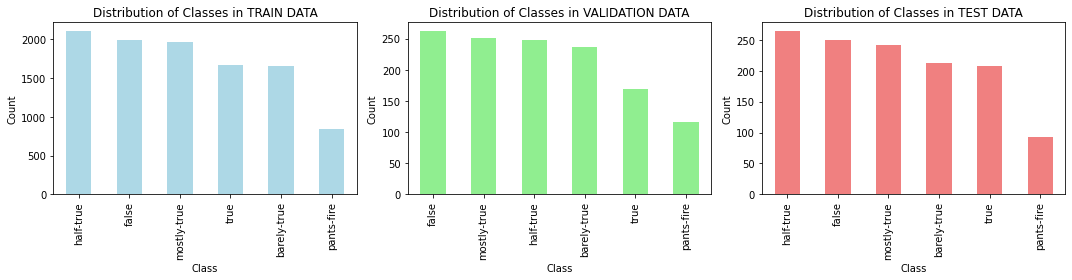

In [5]:
# Plot the distribution of labels
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train['label'].value_counts().plot(kind='bar', ax=axes[0], color='lightblue')
axes[0].set_title('Distribution of Classes in TRAIN DATA')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

validation['label'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Classes in VALIDATION DATA')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

test['label'].value_counts().plot(kind='bar', ax=axes[2], color='lightcoral')
axes[2].set_title('Distribution of Classes in TEST DATA')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
train_clean      = train.copy()
validation_clean = validation.copy()
test_clean       = test.copy()

In [7]:
def combine_fields(row):
    parts=[
        f"speaker: {row['speaker']}",
        f"party: {row['party']}",
        f"job: {row['job']}",
        f"state: {row['state']}",
        f"subject: {row['subject']}",
        f"history: {row['pants_fire_counts']} pants-fire, {row['false_counts']} false, "
        f"{row['barely_true_counts']} barely-true, {row['half_true_counts']} half-true, "
        f"{row['true_counts']} true",
        f"statement: {row['statement']}",
        f"context: {row['context']}"
    ]
    parts = [p for p in parts if 'nan' not in p.lower()]
    return ' '.join(parts)

def clean_text(text):
    text = str(text)

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'#', '', text)

    text = ' '.join(text.split())
    return text


train_clean['text']      = train.apply(combine_fields, axis=1)
validation_clean['text'] = validation.apply(combine_fields, axis=1)
test_clean['text']       = test.apply(combine_fields, axis=1)

train_clean['text']      = train_clean['text'].apply(clean_text)
validation_clean['text'] = validation_clean['text'].apply(clean_text)
test_clean['text']       = test_clean['text'].apply(clean_text)

train_clean      = train_clean.dropna(subset=['label'])
validation_clean = validation_clean.dropna(subset=['label'])
test_clean       = test_clean.dropna(subset=['label'])

print("Train clean shape:     ", train_clean.shape)
print("Validation clean shape:", validation_clean.shape)
print("Test clean shape:      ", test_clean.shape)
print("\nLabel distribution:")
print(train_clean['label'].value_counts())
print(train_clean['label'].value_counts(normalize=True))

Train clean shape:      (10240, 14)
Validation clean shape: (1284, 14)
Test clean shape:       (1267, 14)

Label distribution:
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: label, dtype: int64
half-true      0.206445
false          0.194824
mostly-true    0.191602
true           0.163672
barely-true    0.161523
pants-fire     0.081934
Name: label, dtype: float64


In [8]:
CLASS_NAMES_6 = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
RESULTS_TABLE = []

label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']

# manual mapping to make sure order is correct
label_to_idx = {label: i for i, label in enumerate(label_order)}
idx_to_label = {i: label for i, label in enumerate(label_order)}

y_train_6 = np.array([label_to_idx[l] for l in train_clean['label']])
y_val_6   = np.array([label_to_idx[l] for l in validation_clean['label']])
y_test_6  = np.array([label_to_idx[l] for l in test_clean['label']])

# double check the mapping is correct
print("Label to index:", label_to_idx)
print("Sample encoding:", y_train_6[:5])
print("Should match:  ", list(train_clean['label'][:5]))

# class weights for imbalanced labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(range(6)),
    y=y_train_6
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", dict(zip(label_order, class_weights.round(3))))


def evaluate(model_name, y_true, y_pred, class_names=CLASS_NAMES_6, plot_cm=True):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc         = accuracy_score(y_true, y_pred)
    macro_p     = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    macro_r     = recall_score(y_true, y_pred,    average='macro',    zero_division=0)
    macro_f1    = f1_score(y_true, y_pred,         average='macro',    zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred,         average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Macro Precision : {macro_p:.4f}")
    print(f"  Macro Recall    : {macro_r:.4f}")
    print(f"  Macro F1        : {macro_f1:.4f}")
    print(f"  Weighted F1     : {weighted_f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names, zero_division=0)}")

    if plot_cm:
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, colorbar=True, xticks_rotation=30)
        ax.set_title(f"Confusion Matrix - {model_name}")
        plt.tight_layout()
        plt.show()

    row = {
        'Model'      : model_name,
        'Accuracy'   : round(acc, 4),
        'Macro-P'    : round(macro_p, 4),
        'Macro-R'    : round(macro_r, 4),
        'Macro-F1'   : round(macro_f1, 4),
        'Weighted-F1': round(weighted_f1, 4),
    }
    RESULTS_TABLE.append(row)
    return row


def print_results_table():
    if not RESULTS_TABLE:
        print("No results yet.")
        return
    df = pd.DataFrame(RESULTS_TABLE).set_index('Model')
    print("\n" + "="*65)
    print("  MODEL COMPARISON TABLE")
    print("="*65)
    print(df.to_string())
    print("="*65)
    return df

Label to index: {'pants-fire': 0, 'false': 1, 'barely-true': 2, 'half-true': 3, 'mostly-true': 4, 'true': 5}
Sample encoding: [1 3 4 1 3]
Should match:   ['false', 'half-true', 'mostly-true', 'false', 'half-true']
Class weights: {'pants-fire': 2.034, 'false': 0.855, 'barely-true': 1.032, 'half-true': 0.807, 'mostly-true': 0.87, 'true': 1.018}


In [9]:
#Tokenzier

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(texts, max_length=256):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors=None
    )

print("Tokenising train...")
train_tokens = tokenize(train_clean['text'].tolist())
print("Tokenising validation...")
val_tokens   = tokenize(validation_clean['text'].tolist())
print("Tokenising test...")
test_tokens  = tokenize(test_clean['text'].tolist())
print("Done.")

Tokenising train...
Tokenising validation...
Tokenising test...
Done.


In [10]:
def make_dataloader(tokens, labels, batch_size=16, shuffle=True):
    input_ids      = torch.tensor(tokens['input_ids'])
    attention_mask = torch.tensor(tokens['attention_mask'])
    label_tensor   = torch.tensor(labels, dtype=torch.long)
    dataset = TensorDataset(input_ids, attention_mask, label_tensor)
    sampler = RandomSampler(dataset) if shuffle else SequentialSampler(dataset)
    return DataLoader(dataset, sampler=sampler, batch_size=batch_size)

train_dataloader = make_dataloader(train_tokens, y_train_6, batch_size=16, shuffle=True)
val_dataloader   = make_dataloader(val_tokens,   y_val_6,   batch_size=16, shuffle=False)
test_dataloader  = make_dataloader(test_tokens,  y_test_6,  batch_size=16, shuffle=False)

In [ ]:
EPOCHS = 10

model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=6,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2
)

model.to(device)
model = model.float()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=0.05  
)

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.float())

num_training_steps = EPOCHS * len(train_dataloader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
def calculate_accuracy(preds, labels):
    pred_flat   = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)


In [ ]:
best_val_loss              = float('inf')
patience                   = 2
epochs_without_improvement = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []} 

for epoch in range(EPOCHS):
    print(f"Epoch: {epoch+1}/{EPOCHS}")

    model.train()
    training_loss     = 0
    training_accuracy = 0

    for batch in train_dataloader:
        batch_token_ids      = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels         = batch[2].to(device)

        model.zero_grad()

        outputs = model(
            batch_token_ids,
            attention_mask=batch_attention_mask
        )
        loss = loss_fn(outputs.logits, batch_labels)

        training_loss     += loss.item()
        logits_np          = outputs.logits.detach().cpu().numpy()
        labels_np          = batch_labels.detach().cpu().numpy()
        training_accuracy += calculate_accuracy(logits_np, labels_np)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    average_train_loss = training_loss     / len(train_dataloader)
    avg_train_acc      = training_accuracy / len(train_dataloader)

    model.eval()
    val_loss     = 0
    val_accuracy = 0

    for batch in val_dataloader:
        batch_token_ids      = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels         = batch[2].to(device)

        with torch.no_grad():
            outputs = model(
                batch_token_ids,
                attention_mask=batch_attention_mask
            )
            loss = loss_fn(outputs.logits, batch_labels)

        logits    = outputs.logits.detach().cpu().numpy()
        label_ids = batch_labels.cpu().numpy()
        val_loss     += loss.item()
        val_accuracy += calculate_accuracy(logits, label_ids)

    average_val_loss     = val_loss     / len(val_dataloader)
    average_val_accuracy = val_accuracy / len(val_dataloader)

    history['train_loss'].append(average_train_loss)
    history['val_loss'].append(average_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(average_val_accuracy)

    print(f"Training Loss: {average_train_loss:.4f}")
    print(f"Training Accuracy: {avg_train_acc:.4f}")
    print(f"Validation Loss: {average_val_loss:.4f}")
    print(f"Validation Accuracy: {average_val_accuracy:.4f}")

    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        epochs_without_improvement = 0
        print("New best model saved!")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch: 1/10
Training Loss: 1.8000
Training Accuracy: 0.1492
Validation Loss: 1.7872
Validation Accuracy: 0.1157
New best model saved!
Epoch: 2/10
Training Loss: 1.7552
Training Accuracy: 0.2068
Validation Loss: 1.6363
Validation Accuracy: 0.2415
New best model saved!
Epoch: 3/10
Training Loss: 1.5247
Training Accuracy: 0.3286
Validation Loss: 1.3909
Validation Accuracy: 0.4113
New best model saved!
Epoch: 4/10
Training Loss: 1.3381
Training Accuracy: 0.4378
Validation Loss: 1.3026
Validation Accuracy: 0.4491
New best model saved!
Epoch: 5/10
Training Loss: 1.2719
Training Accuracy: 0.4607
Validation Loss: 1.2624
Validation Accuracy: 0.4421
New best model saved!
Epoch: 6/10
Training Loss: 1.2266
Training Accuracy: 0.4810
Validation Loss: 1.3724
Validation Accuracy: 0.4336
Epoch: 7/10
Training Loss: 1.1900
Training Accuracy: 0.4929
Validation Loss: 1.3438
Validation Accuracy: 0.4367
Early stopping at epoch 7


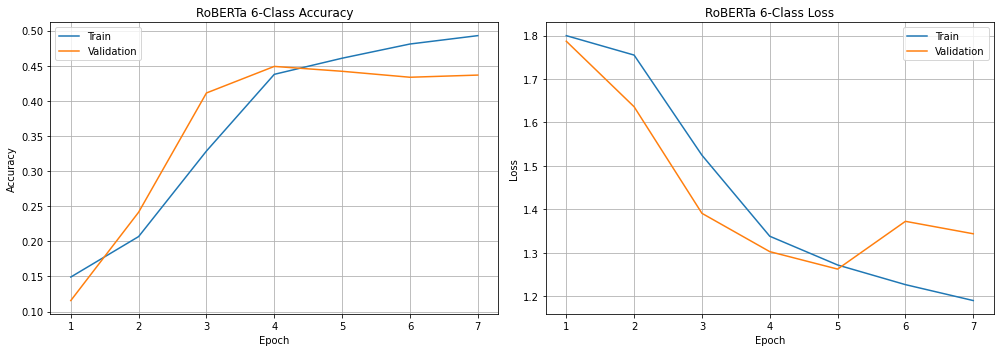

In [18]:
epochs_run = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_run, history['train_acc'], label='Train')
ax1.plot(epochs_run, history['val_acc'],   label='Validation')
ax1.set_title('RoBERTa 6-Class Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_run, history['train_loss'], label='Train')
ax2.plot(epochs_run, history['val_loss'],   label='Validation')
ax2.set_title('RoBERTa 6-Class Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

<ipython-input-15-d5bbf4f03e9c>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt', map_location=device))



  roberta-base (6-class)
  Accuracy        : 0.4380
  Macro Precision : 0.4496
  Macro Recall    : 0.4692
  Macro F1        : 0.4400
  Weighted F1     : 0.4327

              precision    recall  f1-score   support

  pants-fire       0.40      0.76      0.52        92
       false       0.47      0.52      0.49       249
 barely-true       0.45      0.35      0.39       212
   half-true       0.43      0.44      0.44       265
 mostly-true       0.59      0.30      0.40       241
        true       0.36      0.45      0.40       208

    accuracy                           0.44      1267
   macro avg       0.45      0.47      0.44      1267
weighted avg       0.46      0.44      0.43      1267



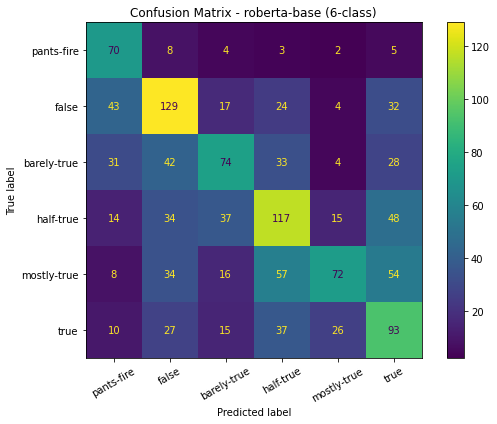

{'Model': 'roberta-base (6-class)',
 'Accuracy': 0.438,
 'Macro-P': 0.4496,
 'Macro-R': 0.4692,
 'Macro-F1': 0.44,
 'Weighted-F1': 0.4327}

In [15]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids      = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels         = batch[2].to(device)
        outputs        = model(input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

evaluate(
    model_name  = "roberta-base (6-class)",
    y_true      = all_labels,
    y_pred      = all_preds,
    class_names = label_order,
    plot_cm     = True
)

              precision  recall  f1-score   support
pants-fire        0.398   0.761     0.522    92.000
false             0.471   0.518     0.493   249.000
barely-true       0.454   0.349     0.395   212.000
half-true         0.432   0.442     0.437   265.000
mostly-true       0.585   0.299     0.396   241.000
true              0.358   0.447     0.397   208.000
accuracy          0.438   0.438     0.438     0.438
macro avg         0.450   0.469     0.440  1267.000
weighted avg      0.458   0.438     0.433  1267.000


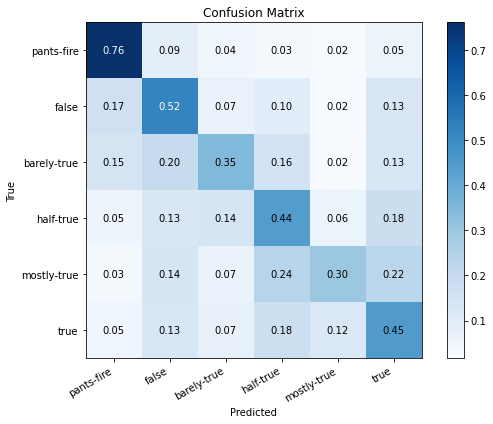

Total errors: 712 / 1267

Top mislabel pairs:
true_label   predicted_label
mostly-true  half-true          57
             true               54
half-true    true               48
false        pants-fire         43
barely-true  false              42
true         half-true          37
half-true    barely-true        37
             false              34
mostly-true  false              34
barely-true  half-true          33
dtype: int64

Error rate by party:
activist               0.500
business-leader          NaN
columnist              0.571
constitution-party     1.000
county-commissioner      NaN
democrat               0.603
government-body          NaN
independent            0.571
journalist             0.444
libertarian              NaN
newsmaker              1.000
none                   0.393
organization           0.148
republican             0.630
state-official           NaN
talk-show-host           NaN
Name: party, dtype: float64

Speaker error rates:
                 total  nu

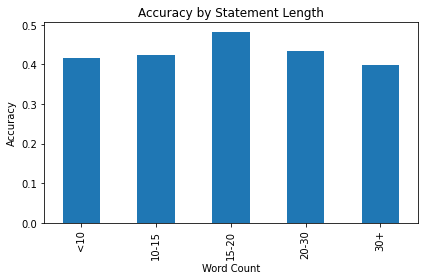


Error distance distribution:
1    332
2    198
3     98
4     69
5     15
Name: distance, dtype: int64


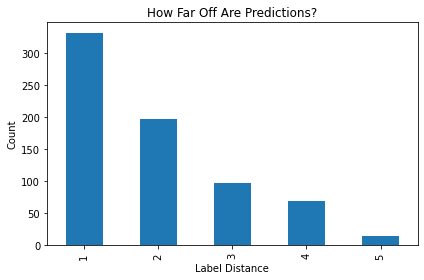

In [19]:
# Per-class breakdown
report_df = pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=label_order, output_dict=True)
).T
print(report_df.round(3))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(6))
ax.set_xticklabels(label_order, rotation=30, ha='right')
ax.set_yticks(range(6))
ax.set_yticklabels(label_order)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
for i in range(6):
    for j in range(6):
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                color='white' if cm[i,j] > 0.5 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

# add predictions to test df so we can look at errors
results_df = test_clean.copy().reset_index(drop=True)
results_df['true_label'] = [idx_to_label[i] for i in all_labels]
results_df['predicted_label'] = [idx_to_label[i] for i in all_preds]
results_df['correct'] = results_df['true_label'] == results_df['predicted_label']

errors = results_df[~results_df['correct']]
print(f"Total errors: {len(errors)} / {len(results_df)}")

# most common mistakes
print("\nTop mislabel pairs:")
print(errors.groupby(['true_label', 'predicted_label']).size().sort_values(ascending=False).head(10))

# error rate by party
print("\nError rate by party:")
print((errors['party'].value_counts() / results_df['party'].value_counts()).round(3))

# which speakers have the highest error rate (only looking at speakers with enough data)
speaker_stats = results_df.groupby('speaker').agg(
    total=('correct', 'count'),
    num_errors=('correct', lambda x: (~x).sum())
)
speaker_stats['error_rate'] = speaker_stats['num_errors'] / speaker_stats['total']
print("\nSpeaker error rates:")
print(speaker_stats[speaker_stats['total'] >= 10].sort_values('error_rate', ascending=False).head(20))

# same for subjects
subject_stats = results_df.groupby('subject').agg(
    total=('correct', 'count'),
    num_errors=('correct', lambda x: (~x).sum())
)
subject_stats['error_rate'] = subject_stats['num_errors'] / subject_stats['total']
print("\nSubject error rates:")
print(subject_stats[subject_stats['total'] >= 10].sort_values('error_rate', ascending=False).head(20))

# does statement length matter
results_df['statement_len'] = results_df['statement'].apply(lambda x: len(str(x).split()))
results_df['len_bin'] = pd.cut(results_df['statement_len'],
                               bins=[0, 10, 15, 20, 30, results_df['statement_len'].max() + 1],
                               labels=['<10', '10-15', '15-20', '20-30', '30+'])
results_df.groupby('len_bin')['correct'].mean().plot(
    kind='bar', title='Accuracy by Statement Length', ylabel='Accuracy', xlabel='Word Count')
plt.tight_layout()
plt.show()

# are errors just off by 1 label or way off
label_to_idx = {label: i for i, label in enumerate(label_order)}
errors = errors.copy()
errors['true_idx'] = errors['true_label'].map(label_to_idx)
errors['pred_idx'] = errors['predicted_label'].map(label_to_idx)
errors['distance'] = (errors['pred_idx'] - errors['true_idx']).abs()

print("\nError distance distribution:")
print(errors['distance'].value_counts().sort_index())

errors['distance'].value_counts().sort_index().plot(
    kind='bar', title='How Far Off Are Predictions?', xlabel='Label Distance', ylabel='Count')
plt.tight_layout()
plt.show()

In [17]:
print(results_df['len_bin'].value_counts().sort_index())

<10      190
10-15    363
15-20    309
20-30    322
30+       83
Name: len_bin, dtype: int64
